In [15]:
!pip install keras keras-hub --upgrade -q
import os
os.environ["KERAS_BACKEND"] = "jax"

In [16]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [35]:
#from keras.datasets import cifar10
from keras.datasets import fashion_mnist as cifar10
# Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [36]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
# x_train = x_train.reshape(-1, 32*32*3)
# x_test = x_test.reshape(-1, 32*32*3)

In [37]:
x_train.shape

(60000, 784)

In [38]:
import keras
from keras import layers
from keras.layers import Input

model = keras.Sequential([
    Input(shape=(784,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [39]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [41]:
x_train.shape

(60000, 784)

In [42]:
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:50000]
y_train = y_train[:50000]

In [43]:
y_train.shape

(50000,)

In [44]:
history = model.fit(
    x_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8225 - loss: 0.4934 - val_accuracy: 0.8433 - val_loss: 0.4262
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8670 - loss: 0.3627 - val_accuracy: 0.8692 - val_loss: 0.3619
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8784 - loss: 0.3295 - val_accuracy: 0.8808 - val_loss: 0.3302
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8886 - loss: 0.3003 - val_accuracy: 0.8790 - val_loss: 0.3379
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8927 - loss: 0.2851 - val_accuracy: 0.8806 - val_loss: 0.3339
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8976 - loss: 0.2676 - val_accuracy: 0.8882 - val_loss: 0.3165
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9024 - loss: 0.2599 - val_accuracy: 0.8828 - val_loss: 0.3287
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9082 - loss: 0.2438 - val_accuracy: 

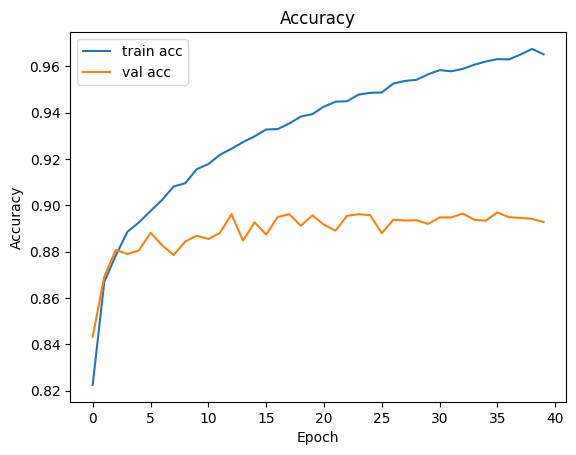

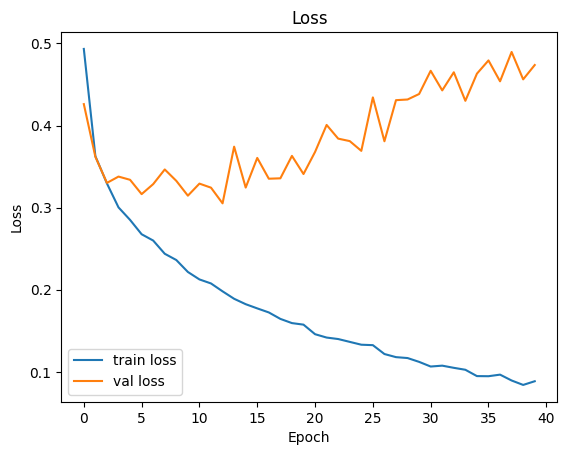

In [45]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [46]:
# We retrain the model to the optimal epochs to avoid overfitting

new_model = keras.Sequential([
    Input(shape=(784,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

new_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = new_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8230 - loss: 0.4930 - val_accuracy: 0.8459 - val_loss: 0.4270
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8649 - loss: 0.3685 - val_accuracy: 0.8633 - val_loss: 0.3688
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8794 - loss: 0.3266 - val_accuracy: 0.8661 - val_loss: 0.3655


In [47]:
#output model
new_model.save('FMnist_FCNN_cifar10_0_8794_adam.keras')